In [38]:
# importamos las librerías que necesitamos

# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Imputación de nulos usando métodos avanzados estadísticos
# -----------------------------------------------------------------------
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer
from itertools import combinations


# Librerías de visualización
# -----------------------------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


# Configuración
# -----------------------------------------------------------------------
# para poder visualizar todas las columnas de los DataFrames
pd.set_option('display.max_columns', None) 

#### ---- INDICE ----  

[- Visualización Inicial](#visualizacion-inicial)  
[- Análisis Descriptivo](#analisis-descriptivo)  
[- Limpieza](#limpieza)  
[- Guardado de archivo limpio](#guardado-de-archivo) 
 
#### ------------------

#### VISUALIZACION INICIAL

In [39]:
# Read the CSV file
# The CSV file is read using pd.read_csv() and stored in the DataFrame df.
df = pd.read_csv('StudentPerformanceFactors_INEE.csv')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'StudentPerformanceFactors_INEE.csv'

In [ ]:
print(f'El DF tiene {df.shape[0]} filas y {df.shape[1]} columnas.')

NameError: name 'df' is not defined

In [ ]:
df.info()

NameError: name 'df' is not defined

#### ANALISIS DESCRIPTIVO

In [ ]:
    # COLUMNAS CATEGÓRICAS --> valores únicos
# Devuelve tablas con las diferentes categorias de las columnas que encontramos en el dataframe
for col in df.select_dtypes(include='O').columns:
    print(f"Las categorías que tenemos para la columna {col} son:")
    display(df[col].value_counts().reset_index())
    print('_' * 100)

IndentationError: expected an indented block after 'for' statement on line 3 (1325266111.py, line 4)

In [ ]:
    # COLUMNAS NUMÉRICAS
# Análisis descriptivo / estadístico
df.select_dtypes(exclude='O').describe().T

NameError: name 'df' is not defined

### LIMPIEZA

In [ ]:
# Comprobamos que no haya valores duplicados:
print(f'Valores duplicados: {df.duplicated().sum()}.')

NameError: name 'df' is not defined

In [ ]:
# Tenemos valores nulos:
    # Sacamos el df con los valores nulos
df_nulos = df.isnull().sum().reset_index()
    # Cambiamos el nombre de las columnas
df_nulos.columns= ['Columnas', 'Valores_Nulos(%)']
    # Nos quedamos con las columnas que tengan valores distintos de 0
df_nulos = df_nulos[df_nulos['Valores_Nulos(%)'] != 0]
    # Añadimos una columna con los porcentajes resultantes
porcentaje_nulos = round(df_nulos['Valores_Nulos(%)']/df.shape[0]*100,2)
df_nulos['Porcentaje_Nulos'] = porcentaje_nulos
df_nulos

NameError: name 'df' is not defined

In [ ]:
# IMPUTACIÓN DE VALORES
# Son variables CATEGÓRICAS con menos del 5% de nulos:
# volvemos a ver los valores únicos:
columnas_cat_nulos = ['Teacher_Quality','Parental_Education_Level','Distance_from_Home']
for col in df_col_nulas[columnas_cat_nulos].columns:
    print(f"Las categorías que tenemos para la columna {col} son:")
    display(df[col].value_counts().reset_index())
    print('_' * 100)

NameError: name 'df_col_nulas' is not defined

In [ ]:
display(df_col_nulas.describe().T)
print('Claramente se ve que la MODA en todas las categorías es clara.')

NameError: name 'df_col_nulas' is not defined

In [ ]:
# Rellenaremos los datos faltantes por la MODA de cada categoría
# iteramos por la lista creada en el paso anterior:
for columna in columnas_cat_nulos:
    # calculamos la moda
    moda = df[columna].mode()[0]    
    # método fillna para reemplazar los valores nulos por la moda
    df[columna] = df[columna].fillna(moda)

# chequeamos si se han eliminado los nulos
print("Después del reemplazo usando 'fillna' quedan los siguientes nulos")
df[columnas_cat_nulos].isnull().sum()

NameError: name 'df' is not defined

### GUARDADO DE ARCHIVO

In [42]:
# Guarda el DataFrame como un archivo CSV
# df.to_csv("SPF_INEE_clean.csv", index=False)

In [43]:
# Read the CSV file
# The CSV file is read using pd.read_csv() and stored in the DataFrame df.
df_clean = pd.read_csv('SPF_INEE_clean.csv')
df_clean.head(2)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61


In [44]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6607 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

CORRELACIÓN ENTRE VARIABLES NUMÉRICAS

In [45]:
numericas = df_clean.select_dtypes(include=np.number)
numericas_comb = list(combinations(numericas, 2))
numericas_comb

[('Hours_Studied', 'Attendance'),
 ('Hours_Studied', 'Sleep_Hours'),
 ('Hours_Studied', 'Previous_Scores'),
 ('Hours_Studied', 'Tutoring_Sessions'),
 ('Hours_Studied', 'Physical_Activity'),
 ('Hours_Studied', 'Exam_Score'),
 ('Attendance', 'Sleep_Hours'),
 ('Attendance', 'Previous_Scores'),
 ('Attendance', 'Tutoring_Sessions'),
 ('Attendance', 'Physical_Activity'),
 ('Attendance', 'Exam_Score'),
 ('Sleep_Hours', 'Previous_Scores'),
 ('Sleep_Hours', 'Tutoring_Sessions'),
 ('Sleep_Hours', 'Physical_Activity'),
 ('Sleep_Hours', 'Exam_Score'),
 ('Previous_Scores', 'Tutoring_Sessions'),
 ('Previous_Scores', 'Physical_Activity'),
 ('Previous_Scores', 'Exam_Score'),
 ('Tutoring_Sessions', 'Physical_Activity'),
 ('Tutoring_Sessions', 'Exam_Score'),
 ('Physical_Activity', 'Exam_Score')]

In [46]:
matrix = numericas.corr()
matrix

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
Hours_Studied,1.000000,-0.009908,0.010977,0.024846,-0.014282,0.004624,0.445455
Attendance,-0.009908,1.000000,-0.015918,-0.020186,0.014324,-0.022435,0.581072
Sleep_Hours,0.010977,-0.015918,1.000000,-0.021750,-0.012216,-0.000378,-0.017022
Previous_Scores,0.024846,-0.020186,-0.021750,1.000000,-0.013122,-0.011274,0.175079
Tutoring_Sessions,-0.014282,0.014324,-0.012216,-0.013122,1.000000,0.017733,0.156525
Physical_Activity,0.004624,-0.022435,-0.000378,-0.011274,0.017733,1.000000,0.027824
Exam_Score,0.445455,0.581072,-0.017022,0.175079,0.156525,0.027824,1.000000


In [47]:
mascara = np.triu(np.ones_like(matrix, dtype=bool))

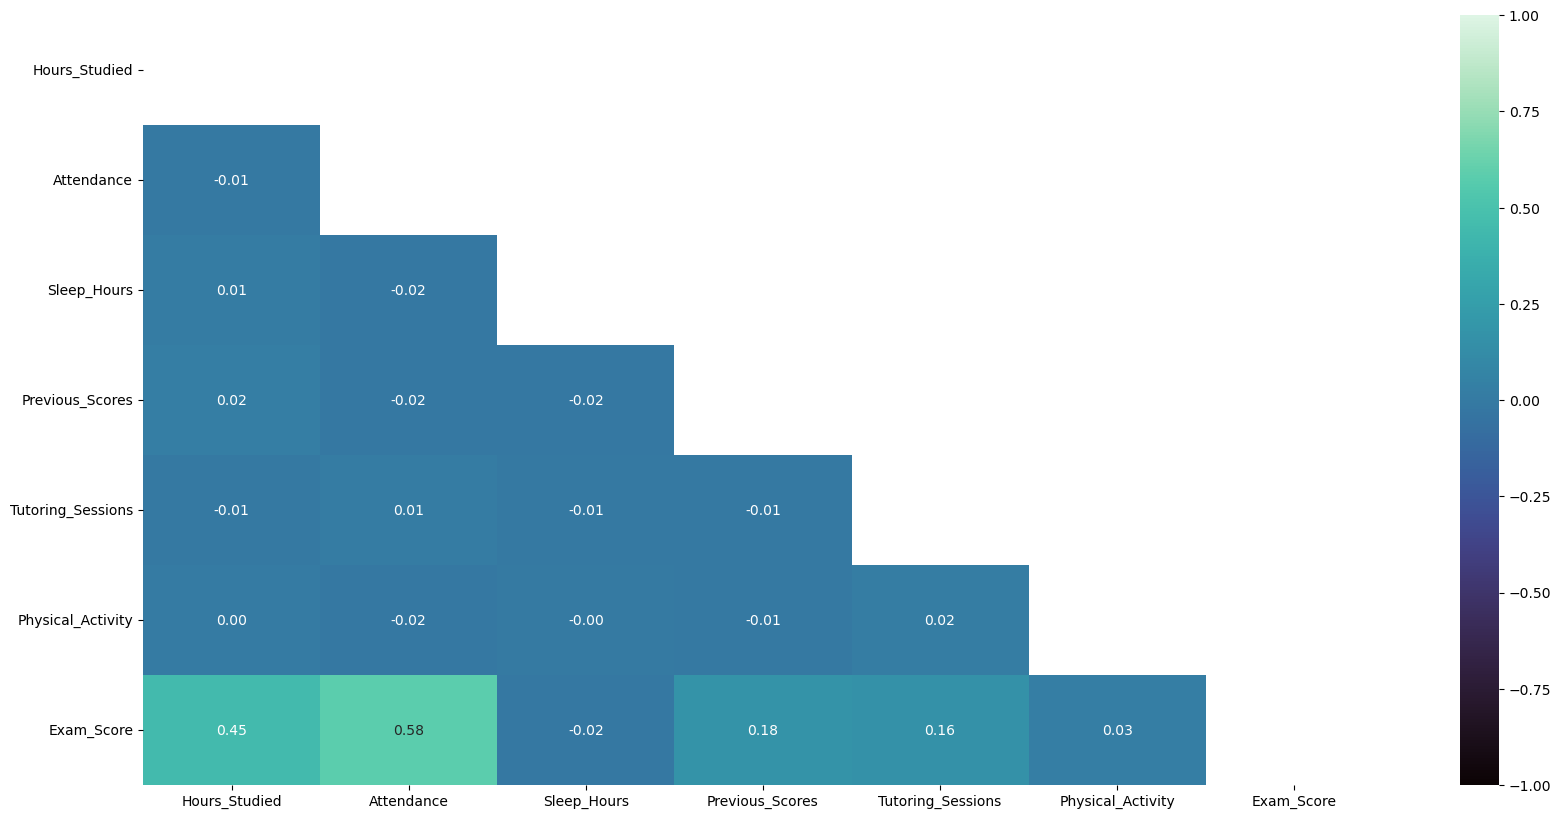

In [48]:
plt.figure(figsize=(20,10))
sns.heatmap(matrix, annot=True, fmt='.2f', cmap= 'mako', vmin=-1, vmax='1', mask = mascara);

SOLO HAY CORRELACIÓN ENTRE LAS NOTAS DEL EXAMEN Y LAS HORAS ESTUDIADAS, Y ENTRE LAS NOTAS DEL EXAMEN Y LA ASISTENCIA A CLASE.

ES DECIR:
LAS HORAS DE SUEÑO, LAS NOTAS PREVIAS, LA CANTIDAD DE SESIONES DE TUTORÍA Y LA ACTIVIDAD FÍSICA NO MUESTRAN CORRELACIÓN CON LAS NOTAS DEL EXAMEN, NI ENTRE ELLAS.
NO HAY CORRELACIÓN ENTRE LAS HORAS ESTUDIADAS Y LA ASISTENCIA A CLASE.

DIFERENCIAS SIGNIFICATIVAS ENTRE EL PROMEDIO DE LA NOTA DEL EXAMEN Y LOS GRUPOS DE CADA VARIABLE CATEGÓRICA

In [49]:
df_clean.describe(include='O').T #resumen de variables categóricas

,count,unique,top,freq
Parental_Involvement,6607,3,Medium,3362
Access_to_Resources,6607,3,Medium,3319
Extracurricular_Activities,6607,2,Yes,3938
Motivation_Level,6607,3,Medium,3351
Internet_Access,6607,2,Yes,6108
Family_Income,6607,3,Low,2672
Teacher_Quality,6607,3,Medium,4003
School_Type,6607,2,Public,4598
Peer_Influence,6607,3,Positive,2638
Learning_Disabilities,6607,2,No,5912


1. PARENTAL ENVOLVEMENT - MÉTODO VISTO EN CLASE

In [50]:
df_clean["Parental_Involvement"].value_counts()

Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64

In [51]:
# GRUPOS A COOMPARAR

Medium= df_clean[df_clean['Parental_Involvement'] == 'Medium']['Exam_Score']
High = df_clean[df_clean['Parental_Involvement'] == 'High']['Exam_Score']
Low = df_clean[df_clean['Parental_Involvement'] == 'Low']['Exam_Score']

print(Medium.head(2))
print(High.head(2))
print(Low.head(2))

2    74
4    70
Name: Exam_Score, dtype: int64
23    66
25    64
Name: Exam_Score, dtype: int64
0    67
1    61
Name: Exam_Score, dtype: int64


<Axes: xlabel='Parental_Involvement', ylabel='Exam_Score'>

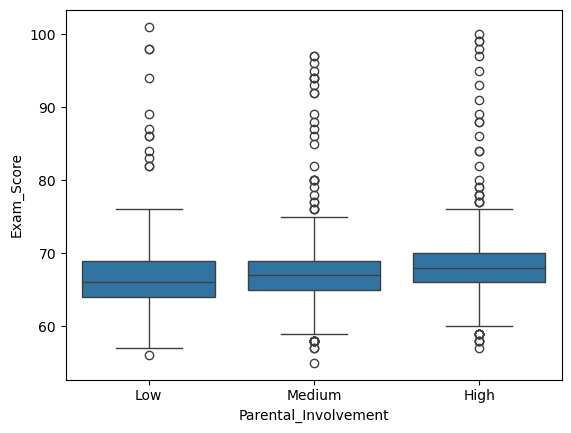

In [52]:
sns.boxplot(data=df_clean, x="Parental_Involvement", y="Exam_Score") #MUCHOS OUTLIERS, USAR MEDIANA

In [53]:
print(df_clean.groupby("Parental_Involvement")["Exam_Score"].median())

Parental_Involvement
High      68.0
Low       66.0
Medium    67.0
Name: Exam_Score, dtype: float64


In [54]:
grupos = [Low, Medium, High]

# Definimos nivel significancia en 0.05
for grupo in grupos:
    p_value_norm = stats.kstest(grupo, 'norm').pvalue
    
    if p_value_norm > 0.05:
        print(f"La distribución de la cantidad de vuelos reservados para este grupo es normal")
    else:
        print(f"La distribución de la cantidad de vuelos reservados para este grupo no sigue una distribución normal")
    
print("_"*150)


La distribución de la cantidad de vuelos reservados para este grupo no sigue una distribución normal
La distribución de la cantidad de vuelos reservados para este grupo no sigue una distribución normal
La distribución de la cantidad de vuelos reservados para este grupo no sigue una distribución normal
______________________________________________________________________________________________________________________________________________________


In [55]:
# Como la distribucion no es normal, tenemos 3 grupos con una misma variable independiente ordinal con varios niveles,
#  aplicamos la prueba Kruskal Wallis (comparación por medianas)

p_value_kruskal = stats.kruskal(Low, Medium, High).pvalue

if p_value_kruskal > 0.05:
    print(f"No podemos rechazar la hipótesis nula, así que consideramos que no hay diferencias significativas entre grupos")
else:
    print(f"Rechazamos la hipótesis nula y aceptamos la alternativa, los grupos son distintos")

Rechazamos la hipótesis nula y aceptamos la alternativa, los grupos son distintos


In [56]:
def prueba_hipotesis(alfa, *args):

    # Verificar si hay al menos dos grupos
    if len(args) < 2:
        raise ValueError("Se necesitan al menos dos conjuntos de datos para realizar la prueba.")
    
    # Comprobar normalidad en cada grupo
    normalidad = []
    for grupo in args:
        if len(grupo) > 50:
            p_valor_norm = stats.kstest(grupo, 'norm').pvalue  # Kolmogorov-Smirnov si n > 50
        else:
            p_valor_norm = stats.shapiro(grupo).pvalue  # Shapiro-Wilk si n <= 50
        normalidad.append(p_valor_norm > 0.05)

    datos_normales = all(normalidad)  # True si todos los grupos son normales

    # Prueba de igualdad de varianzas
    if datos_normales:
        p_valor_varianza = stats.bartlett(*args).pvalue  # Test de Bartlett si los datos son normales
    else:
        p_valor_varianza = stats.levene(*args, center="median").pvalue  # Test de Levene si no son normales

    varianzas_iguales = p_valor_varianza > 0.05

    # Aplicar el test adecuado
    if datos_normales:
        if varianzas_iguales:
            p_valor = stats.ttest_ind(*args, equal_var=True).pvalue
            test_usado = "t-test de Student (varianzas iguales)"
        else:
            p_valor = stats.ttest_ind(*args, equal_var=False).pvalue
            test_usado = "t-test de Welch (varianzas desiguales)"
    else:
        try: # si tengo dos grupos
            p_valor = stats.mannwhitneyu(*args).pvalue
            test_usado = "Mann-Whitney U (prueba no paramétrica)"
        except: # si tengo mas de dos grupos
            p_valor = stats.kruskal(*args).pvalue
            test_usado = "Kruskal Wallis"



    # Nivel de significancia
    alfa = alfa

    # Resultados
    resultado = {
        "Test de Normalidad": normalidad,
        "Datos Normales": datos_normales,
        "p-valor Varianza": p_valor_varianza,
        "Varianzas Iguales": varianzas_iguales,
        "Test Usado": test_usado,
        "p-valor": p_valor,
        "Conclusión": "Rechazamos H0 (Diferencias significativas)" if p_valor < alfa else "No se rechaza H0 (No hay diferencias significativas)"
    }

    # Imprimir resultados de manera más clara
    print("\n📊 **Resultados de la Prueba de Hipótesis** 📊")
    print(f"✅ Test de Normalidad: {'Sí' if datos_normales else 'No'}")
    print(f"   - Normalidad por grupo: {normalidad}")
    print(f"✅ Test de Varianza: {'Iguales' if varianzas_iguales else 'Desiguales'} (p = {p_valor_varianza:.4f})")
    print(f"✅ Test aplicado: {test_usado}")
    print(f" p-valor: {p_valor:.4f}")
    print(f"🔍 Conclusión: {resultado['Conclusión']}\n")

    return resultado

In [57]:
prueba_hipotesis(0.05, Low, Medium, High)


📊 **Resultados de la Prueba de Hipótesis** 📊
✅ Test de Normalidad: No
   - Normalidad por grupo: [False, False, False]
✅ Test de Varianza: Iguales (p = 0.6579)
✅ Test aplicado: Kruskal Wallis
 p-valor: 0.0000
🔍 Conclusión: Rechazamos H0 (Diferencias significativas)



{'Test de Normalidad': [False, False, False],
 'Datos Normales': False,
 'p-valor Varianza': 0.6579066222919269,
 'Varianzas Iguales': True,
 'Test Usado': 'Kruskal Wallis',
 'p-valor': 2.8545406295009852e-43,
 'Conclusión': 'Rechazamos H0 (Diferencias significativas)'}

FORMA 2 - EFECTIVAMENTE HAY DIFERENCIAS SIGNIFICATIVAS

In [58]:
print(df_clean.groupby("Parental_Involvement")["Exam_Score"].median())


Parental_Involvement
High      68.0
Low       66.0
Medium    67.0
Name: Exam_Score, dtype: float64


In [59]:
grupos2 = [g["Exam_Score"].values for _, g in df_clean.groupby("Parental_Involvement")]
stat, p = kruskal(*grupos2)
print("H =", stat, "p =", p)

NameError: name 'kruskal' is not defined

In [ ]:
resultado = sp.posthoc_dunn(df_clean, val_col='Exam_Score', group_col='Parental_Involvement', p_adjust='bonferroni')
print(resultado)

                High           Low        Medium
High    1.000000e+00  1.263241e-42  7.212644e-20
Low     1.263241e-42  1.000000e+00  8.297121e-12
Medium  7.212644e-20  8.297121e-12  1.000000e+00


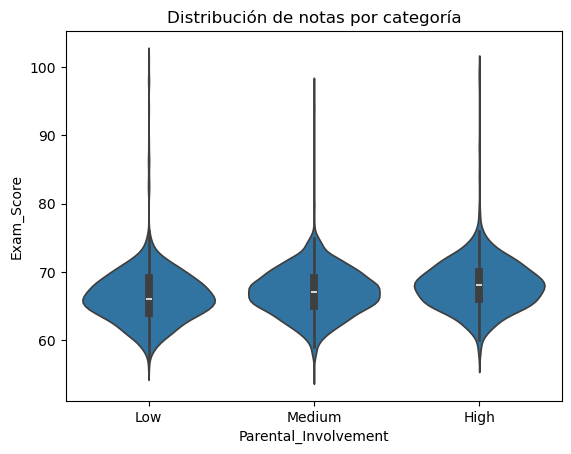

In [ ]:
sns.violinplot(data=df_clean, x='Parental_Involvement', y='Exam_Score', inner='box')
plt.title("Distribución de notas por categoría")
plt.show()

EN CONJUNTO, TODAS LAS VARIABLES A LA VEZ

DE 3 GRUPOS
    'Parental_Involvement',
    'Access_to_Resources',
    'Motivation_Level',
    'Family_Income',
    'Teacher_Quality',
    'Peer_Influence',
    'Parental_Education_Level',
    'Distance_from_Home

DE 2 GRUPOS
   'Gender',
    'Learning_Disabilities',
    'Internet_Access',
    'Extracurricular_Activities',
    'School_Type'

In [ ]:
import pandas as pd
import scikit_posthocs as sp
from scipy.stats import kruskal

categorical_cols = ['Parental_Involvement','Access_to_Resources','Motivation_Level', 
                    'Family_Income', 'Teacher_Quality', 'Peer_Influence',
                    'Parental_Education_Level','Distance_from_Home']

# Lista para almacenar resultados
summary_results = []

for cat in categorical_cols:
    # Kruskal-Wallis
    groups = [g['Exam_Score'].values for _, g in df_clean.groupby(cat)]
    H, p = kruskal(*groups)
    
    # Crear diccionario temporal
    temp_dict = {'Variable': cat, 'Kruskal_H': H, 'Kruskal_p': p}
    
    if p < 0.05:
        temp_dict['Significant'] = True
        # Dunn post-hoc
        posthoc = sp.posthoc_dunn(df_clean, val_col='Exam_Score', group_col=cat, p_adjust='bonferroni')
        # Detectar pares significativos
        significant_pairs = []
        for i in posthoc.index:
            for j in posthoc.columns:
                if i != j and posthoc.loc[i,j] < 0.05:
                    pair = tuple(sorted([i,j]))
                    if pair not in significant_pairs:
                        significant_pairs.append(pair)
        temp_dict['Significant_Pairs'] = significant_pairs
    else:
        temp_dict['Significant'] = False
        temp_dict['Significant_Pairs'] = []

    summary_results.append(temp_dict)

# Convertir a DataFrame
summary_df = pd.DataFrame(summary_results)

# Mostrar la tabla
print(summary_df)

                   Variable   Kruskal_H     Kruskal_p  Significant  \
0      Parental_Involvement  195.924496  2.854541e-43         True   
1       Access_to_Resources  231.678249  4.917083e-51         True   
2          Motivation_Level   59.085248  1.478432e-13         True   
3             Family_Income   63.800355  1.399358e-14         True   
4           Teacher_Quality   44.903419  1.775606e-10         True   
5            Peer_Influence   84.991297  3.502469e-19         True   
6  Parental_Education_Level   93.241200  5.661490e-21         True   
7        Distance_from_Home   67.818249  1.876957e-15         True   

                                   Significant_Pairs  
0       [(High, Low), (High, Medium), (Low, Medium)]  
1       [(High, Low), (High, Medium), (Low, Medium)]  
2       [(High, Low), (High, Medium), (Low, Medium)]  
3       [(High, Low), (High, Medium), (Low, Medium)]  
4       [(High, Low), (High, Medium), (Low, Medium)]  
5  [(Negative, Neutral), (Negative, Pos

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

categorical_cols = ['Gender', 'Learning_Disabilities', 'Internet_Access', 'Extracurricular_Activities','School_Type']

# Lista para almacenar resultados
summary_results_2groups = []

for cat in categorical_cols:
    grupos = df_clean[cat].unique()
    
    if len(grupos) != 2:
        print(f"⚠️ {cat} no tiene 2 grupos, se omite.")
        continue
    
    # Extraer los valores
    grupo1 = df_clean[df_clean[cat] == grupos[0]]['Exam_Score']
    grupo2 = df_clean[df_clean[cat] == grupos[1]]['Exam_Score']
    
    # Mann-Whitney U test
    stat, p = mannwhitneyu(grupo1, grupo2, alternative='two-sided')
    
    # Guardar resultados
    temp_dict = {
        'Variable': cat,
        'Group1': grupos[0],
        'Group2': grupos[1],
        'U_stat': stat,
        'p_value': p,
        'Significant': p < 0.05
    }
    
    summary_results_2groups.append(temp_dict)

# Convertir a DataFrame
summary_df_2groups = pd.DataFrame(summary_results_2groups)

# Mostrar la tabla
print(summary_df_2groups)

                     Variable  Group1   Group2     U_stat       p_value  \
0                      Gender    Male   Female  5372067.5  5.481443e-01   
1       Learning_Disabilities      No      Yes  2427542.0  3.410899e-15   
2             Internet_Access     Yes       No  1730783.5  4.009169e-07   
3  Extracurricular_Activities      No      Yes  4860705.5  1.924056e-07   
4                 School_Type  Public  Private  4552099.5  3.485872e-01   

   Significant  
0        False  
1         True  
2         True  
3         True  
4        False  


                      Variable            Test       p_value  Significant  \
0         Parental_Involvement  Kruskal-Wallis  2.854541e-43            1   
1          Access_to_Resources  Kruskal-Wallis  4.917083e-51            1   
2             Motivation_Level  Kruskal-Wallis  1.478432e-13            1   
3                Family_Income  Kruskal-Wallis  1.399358e-14            1   
4              Teacher_Quality  Kruskal-Wallis  1.775606e-10            1   
5               Peer_Influence  Kruskal-Wallis  3.502469e-19            1   
6     Parental_Education_Level  Kruskal-Wallis  5.661490e-21            1   
7           Distance_from_Home  Kruskal-Wallis  1.876957e-15            1   
8                       Gender    Mann-Whitney  5.481443e-01            0   
9        Learning_Disabilities    Mann-Whitney  3.410899e-15            1   
10             Internet_Access    Mann-Whitney  4.009169e-07            1   
11  Extracurricular_Activities    Mann-Whitney  1.924056e-07            1   

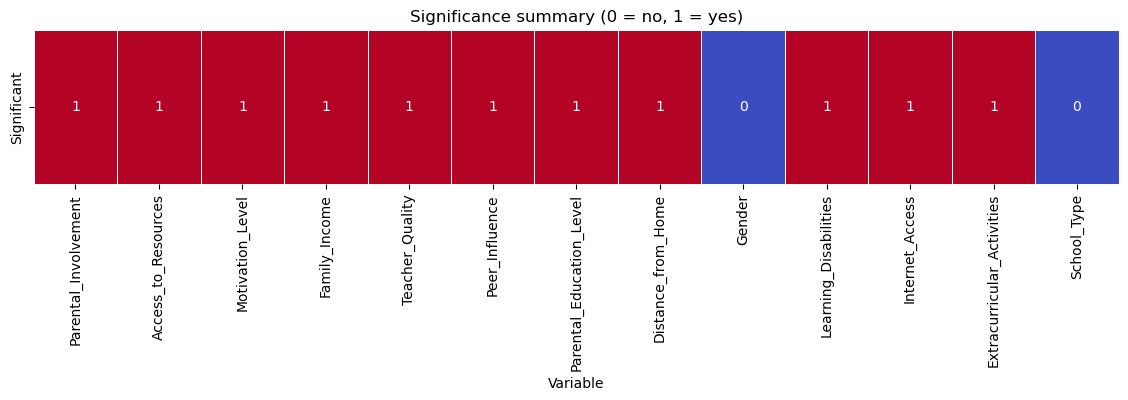

In [ ]:
import pandas as pd
import scikit_posthocs as sp
from scipy.stats import kruskal, mannwhitneyu
import seaborn as sns
import matplotlib.pyplot as plt

# Columnas
categorical_cols_2plus = ['Parental_Involvement','Access_to_Resources','Motivation_Level', 
                          'Family_Income', 'Teacher_Quality', 'Peer_Influence',
                          'Parental_Education_Level','Distance_from_Home']

categorical_cols_2groups = ['Gender', 'Learning_Disabilities', 'Internet_Access', 'Extracurricular_Activities','School_Type']

summary_results = []

# --- Variables >= 2 grupos (Kruskal-Wallis) ---
for cat in categorical_cols_2plus:
    groups = [g['Exam_Score'].values for _, g in df_clean.groupby(cat)]
    H, p = kruskal(*groups)
    
    temp_dict = {
        'Variable': cat,
        'Test': 'Kruskal-Wallis',
        'p_value': p,
        'Significant': int(p < 0.05),
        'Significant_Pairs': []
    }
    
    if p < 0.05:
        # Dunn post-hoc
        posthoc = sp.posthoc_dunn(df_clean, val_col='Exam_Score', group_col=cat, p_adjust='bonferroni')
        significant_pairs = []
        for i in posthoc.index:
            for j in posthoc.columns:
                if i != j and posthoc.loc[i,j] < 0.05:
                    pair = tuple(sorted([i,j]))
                    if pair not in significant_pairs:
                        significant_pairs.append(pair)
        temp_dict['Significant_Pairs'] = significant_pairs
    
    summary_results.append(temp_dict)

# --- Variables de 2 grupos (Mann-Whitney) ---
for cat in categorical_cols_2groups:
    grupos = df_clean[cat].unique()
    if len(grupos) != 2:
        print(f"⚠️ {cat} no tiene 2 grupos, se omite.")
        continue
    
    grupo1 = df_clean[df_clean[cat] == grupos[0]]['Exam_Score']
    grupo2 = df_clean[df_clean[cat] == grupos[1]]['Exam_Score']
    
    stat, p = mannwhitneyu(grupo1, grupo2, alternative='two-sided')
    
    temp_dict = {
        'Variable': cat,
        'Test': 'Mann-Whitney',
        'p_value': p,
        'Significant': int(p < 0.05),
        'Significant_Pairs': []  # No aplica para 2 grupos
    }
    summary_results.append(temp_dict)

# Convertir a DataFrame combinado
summary_df_combined = pd.DataFrame(summary_results)

# Mostrar tabla completa
print(summary_df_combined)

# --- Heatmap de significancia 0/1 ---
heatmap_data = summary_df_combined.set_index('Variable')['Significant'].to_frame().T

plt.figure(figsize=(14, 2))
sns.heatmap(heatmap_data, annot=True, cbar=False, cmap="coolwarm", linewidths=0.5)
plt.title("Significance summary (0 = no, 1 = yes)")
plt.savefig(r"C:\Users\aniet\Downloads\heatmap_significance.png", dpi=300, bbox_inches='tight')
plt.show()

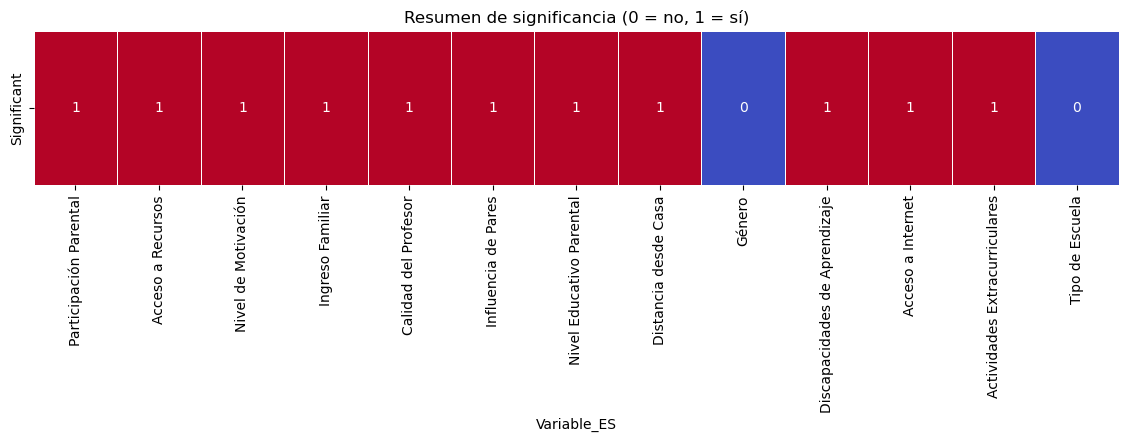

In [ ]:
traducciones = {
    'Parental_Involvement': 'Participación Parental',
    'Access_to_Resources': 'Acceso a Recursos',
    'Motivation_Level': 'Nivel de Motivación',
    'Family_Income': 'Ingreso Familiar',
    'Teacher_Quality': 'Calidad del Profesor',
    'Peer_Influence': 'Influencia de Pares',
    'Parental_Education_Level': 'Nivel Educativo Parental',
    'Distance_from_Home': 'Distancia desde Casa',
    'Gender': 'Género',
    'Learning_Disabilities': 'Discapacidades de Aprendizaje',
    'Internet_Access': 'Acceso a Internet',
    'Extracurricular_Activities': 'Actividades Extracurriculares',
    'School_Type': 'Tipo de Escuela'
}

# Convertir nombres de variables en la tabla de resumen
summary_df_combined['Variable_ES'] = summary_df_combined['Variable'].map(traducciones)

# --- Heatmap de significancia 0/1 ---
heatmap_data = summary_df_combined.set_index('Variable_ES')['Significant'].to_frame().T

plt.figure(figsize=(14, 2))
sns.heatmap(heatmap_data, annot=True, cbar=False, cmap="coolwarm", linewidths=0.5)
plt.title("Resumen de significancia (0 = no, 1 = sí)")
plt.savefig(r"C:\Users\aniet\Downloads\heatmap_significance.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
SOLO LAS VARIABLES GÉNERO Y TIPO DE ESCUELA NO MUESTRAN DIFERENCIAS SIGNIFICATIVAS CON RESPECTO A LA NOTA DEL EXAMEN.
TODAS LAS DEMÁS VARIABLES SÍ MUESTRAN DIFERENCIAS SIGNIFICATIVAS.

RESUMEN DE ESTADÍSTICAS DESCRIPTIVAS DE LAS VARIABLES

In [ ]:
df_clean.describe().round(2)

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00
mean,19.98,79.98,7.03,75.07,1.49,2.97,67.24
std,5.99,11.55,1.47,14.40,1.23,1.03,3.89
min,1.00,60.00,4.00,50.00,0.00,0.00,55.00
25%,16.00,70.00,6.00,63.00,1.00,2.00,65.00
50%,20.00,80.00,7.00,75.00,1.00,3.00,67.00
75%,24.00,90.00,8.00,88.00,2.00,4.00,69.00
max,44.00,100.00,10.00,100.00,8.00,6.00,101.00
